# Task 5: Personal Loan Acceptance Prediction

This task aims to predict which customers are likely to accept a loan offer.

In [1]:
import pandas as pd

df = pd.read_csv("bank.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## Dataset Overview

This dataset contains customer information such as age, job, marital status, and whether they accepted a loan.

In [2]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

## Data Understanding

The dataset contains both categorical and numerical variables.
The target variable is 'y' which indicates loan acceptance.

## EDA

The following graphs show how customer categories relate to deposit acceptance.

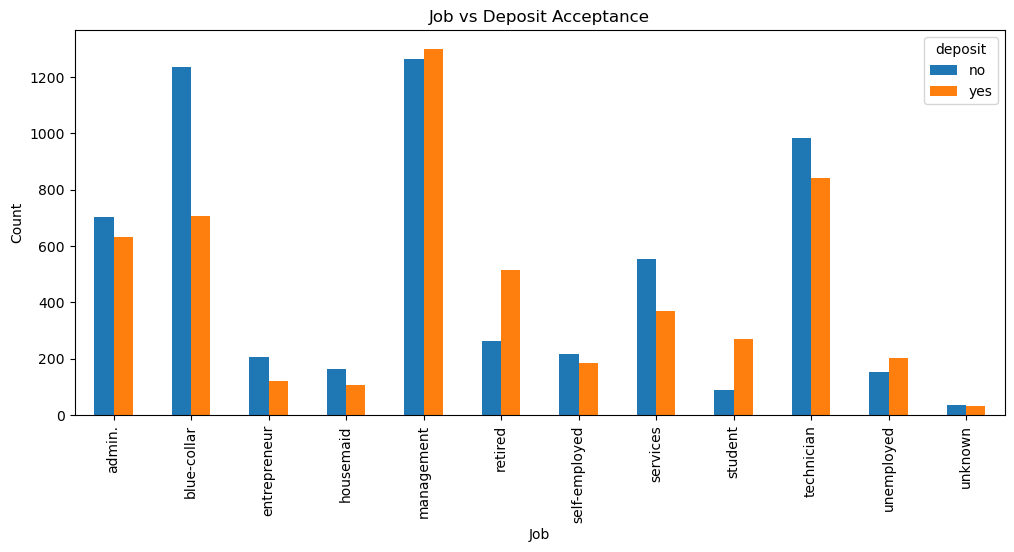

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

pd.crosstab(df['job'], df['deposit']).plot(kind='bar', figsize=(12,5))
plt.title("Job vs Deposit Acceptance")
plt.xlabel("Job")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

This graph shows how different job types affect deposit acceptance.

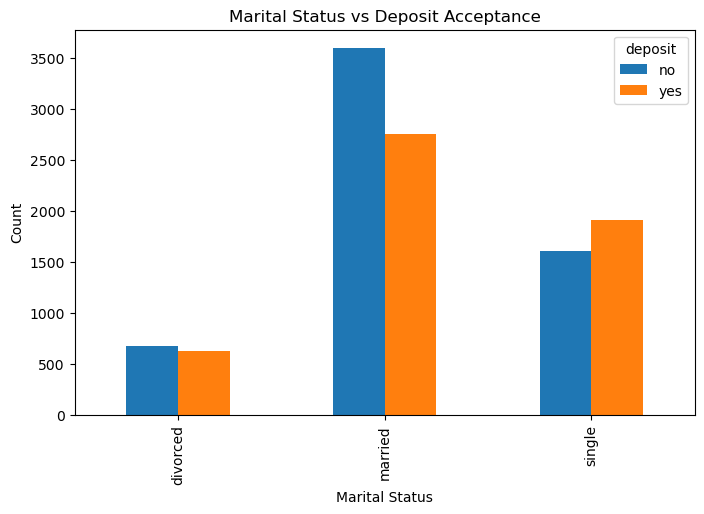

In [11]:
pd.crosstab(df['marital'], df['deposit']).plot(kind='bar', figsize=(8,5))
plt.title("Marital Status vs Deposit Acceptance")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.show()

This graph shows how marital status affects deposit acceptance.

In [12]:
df = pd.get_dummies(df, drop_first=True)

## Data Encoding

Categorical variables were converted into numerical format.

In [13]:
df.columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'education_secondary',
       'education_tertiary', 'education_unknown', 'default_yes', 'housing_yes',
       'loan_yes', 'contact_telephone', 'contact_unknown', 'month_aug',
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown',
       'deposit_yes'],
      dtype='object')

In [15]:
X = df.drop('deposit_yes', axis=1)
y = df['deposit_yes']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Data Splitting

The dataset is divided into training and testing sets.

In [17]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Model Training

Decision Tree model is used to predict deposit acceptance.

In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7895208240035826
Confusion Matrix:
 [[938 228]
 [242 825]]


## Insights

Job type and marital status appear to influence deposit acceptance. The model helps identify which customers are more likely to accept the offer.

<Axes: xlabel='deposit', ylabel='count'>

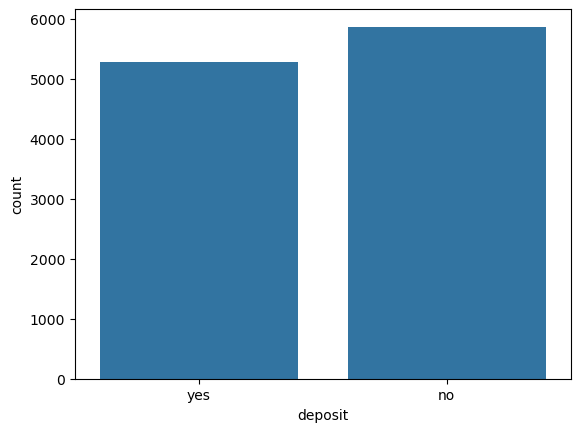

In [20]:
import seaborn as sns

sns.countplot(x='deposit', data=pd.read_csv("bank.csv"))

This shows overall loan acceptance distribution.

## Conclusion

- Data was explored and visualized.
- Categorical variables were encoded.
- A Decision Tree model was trained.
- The model predicts deposit acceptance based on customer information.